# Лабораторная работа 16 — Ассоциативные правила

**Цель:** найти ассоциативные правила в транзакционных данных (market basket analysis) с помощью алгоритма Apriori для некоторой торговой фирмы.

**Датасет (по заданию):** [Market Basket Optimisation](https://www.kaggle.com/d4rklucif3r/market-basket-optimisation) — 7501 чек продуктового магазина, 120 уникальных товаров, без заголовков (каждая строка — одна корзина).

**Параметры Apriori (из задания):** `min_support=0.003, min_confidence=0.2, min_lift=4, min_length=2`.

**Что нужно сделать (по пунктам задания):**
1. Построить ассоциативные правила.
2. Провести анализ рыночной корзины.
3. Найти: (а) правила, представляющие интерес; (б) правило с максимальным lift; (в) товары, которые покупают вместе с поздравительной открыткой и какая ассоциация имеет наибольший lift.

Дополнительно в [`lab16_gtzan.ipynb`](lab16_gtzan.ipynb) — исследование применимости Apriori к GTZAN через бинаризацию признаков (бонус, не часть задания).

## Теория

**Ассоциативное правило** $X \Rightarrow Y$ означает: «если в корзине есть набор $X$, то с высокой вероятностью есть и $Y$». Например, $\{хлеб, масло\} \Rightarrow \{молоко\}$.

**Метрики:**

$$\text{support}(X) = \frac{|\{T : X \subseteq T\}|}{|D|}$$

Доля транзакций, содержащих $X$. Чем выше — тем чаще набор встречается.

$$\text{confidence}(X \Rightarrow Y) = \frac{\text{support}(X \cup Y)}{\text{support}(X)}$$

Условная вероятность $P(Y \mid X)$ — насколько надёжно $X$ предсказывает $Y$.

$$\text{lift}(X \Rightarrow Y) = \frac{\text{confidence}(X \Rightarrow Y)}{\text{support}(Y)} = \frac{P(X \cap Y)}{P(X) \cdot P(Y)}$$

Во сколько раз вероятность увидеть $Y$ при условии $X$ выше, чем без условия. **lift > 1** — положительная ассоциация; **lift = 1** — независимость; **lift < 1** — отрицательная.

**Алгоритм Apriori** строит частые наборы поэтапно (одиночки → пары → тройки), используя свойство монотонности: **если набор не частый, то и его надмножества не частые** — это срезает экспоненциальное пространство поиска.

## 1. Установка зависимостей

Раскомментируйте, если `apyori` не установлен. Для надёжности ниже есть автоматический fallback на `mlxtend` (метрики идентичны, реализация на C → быстрее).

In [12]:
# !pip install apyori

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Загрузка датасета

Файл `Market_Basket_Optimisation.csv` лежит в `datasets/` (скачан с [Kaggle](https://www.kaggle.com/d4rklucif3r/market-basket-optimisation), как указано в задании). Особенности структуры:
- **Нет заголовков** (`header=None`) — первая строка уже данные.
- Каждая строка — отдельная корзина с переменным числом товаров (от 1 до 20).
- Пустые позиции в строке = `NaN`.

In [14]:
DATA_PATH = Path('../../datasets/Market_Basket_Optimisation.csv')
dataset = pd.read_csv(DATA_PATH, header=None)
print(f'Размер датасета: {dataset.shape[0]} строк (чеков), {dataset.shape[1]} столбцов товаров')
dataset.head()

Размер датасета: 7501 строк (чеков), 20 столбцов товаров


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Преобразование в транзакции

Превращаем DataFrame в список транзакций: каждая транзакция — список уникальных товаров в чеке (NaN отбрасываем, дубликаты внутри чека убираем через `set`).

In [15]:
transactions = []
for i in range(len(dataset)):
    row = dataset.iloc[i].dropna().astype(str).tolist()
    transactions.append(sorted(set(row)))

lens = pd.Series([len(t) for t in transactions])
print(f'Статистика длин чеков:')
print(f'  Min: {lens.min()},  Max: {lens.max()},  Mean: {lens.mean():.2f},  Median: {int(lens.median())}')

all_items = [item for tr in transactions for item in tr]
n_unique = len(set(all_items))
print(f'\nУникальных товаров: {n_unique}')
print(f'Всего товаров (с повторами): {len(all_items)}')

Статистика длин чеков:
  Min: 1,  Max: 20,  Mean: 3.91,  Median: 3

Уникальных товаров: 120
Всего товаров (с повторами): 29358


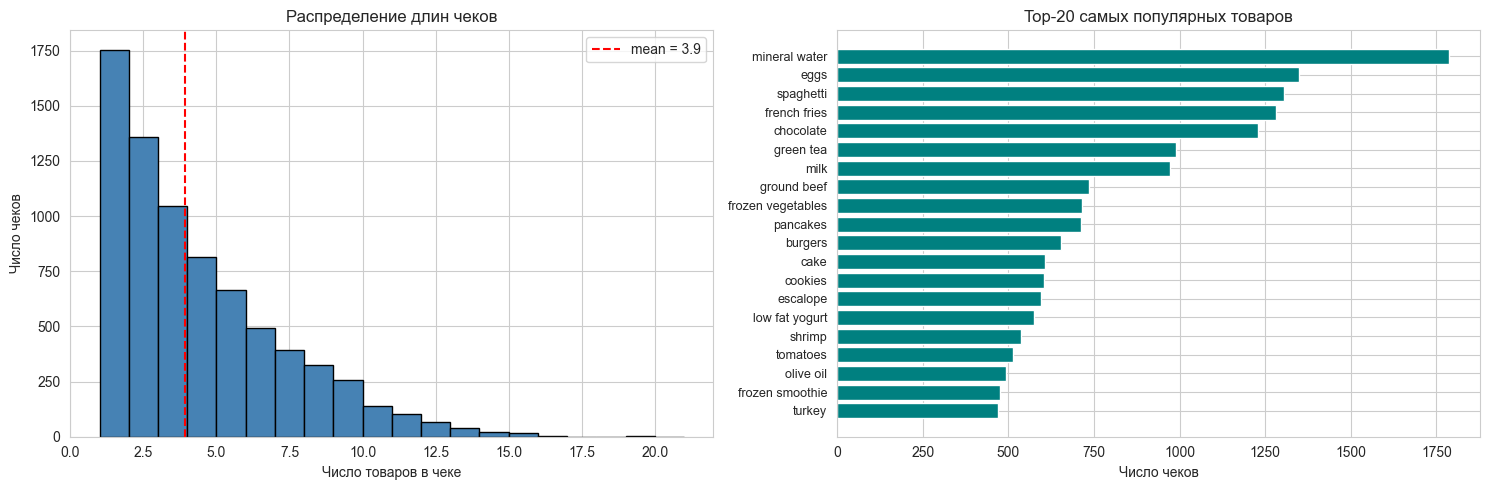

In [16]:
# EDA: распределение длин чеков и top-20 товаров
top_items = Counter(all_items).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(lens, bins=range(1, lens.max() + 2), color='steelblue', edgecolor='black')
axes[0].axvline(lens.mean(), color='red', linestyle='--', label=f'mean = {lens.mean():.1f}')
axes[0].set_xlabel('Число товаров в чеке')
axes[0].set_ylabel('Число чеков')
axes[0].set_title('Распределение длин чеков')
axes[0].legend()

names, counts = zip(*top_items)
axes[1].barh(range(len(names)), counts, color='teal')
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Число чеков')
axes[1].set_title('Top-20 самых популярных товаров')

plt.tight_layout()
plt.show()

## 4. Применение Apriori (пункт 1 задания)

Запускаем алгоритм с параметрами **из задания**:
- `min_support = 0.003` — товар/набор должен встречаться хотя бы в 0.3% чеков (~22 чека из 7501).
- `min_confidence = 0.2` — правило верно минимум в 20% случаев.
- `min_lift = 4` — связь между антецедентом и консеквентом должна быть в **4 раза сильнее случайной**.
- `min_length = 2` — пропускаем тривиальные одиночки.

Если `apyori` не установлен — автоматически переключаемся на `mlxtend.frequent_patterns.apriori` с теми же порогами (формулы метрик идентичны, реализация на C → быстрее).

In [17]:
MIN_SUPPORT = 0.003
MIN_CONF    = 0.2
MIN_LIFT    = 4
MIN_LENGTH  = 2

rules_df = None
backend = None
try:
    from apyori import apriori as apyori_apriori
    results = list(apyori_apriori(
        transactions,
        min_support=MIN_SUPPORT,
        min_confidence=MIN_CONF,
        min_lift=MIN_LIFT,
        min_length=MIN_LENGTH,
    ))
    rows = []
    for record in results:
        for stat in record.ordered_statistics:
            if not stat.items_base:
                continue
            rows.append({
                'antecedent': ', '.join(sorted(stat.items_base)),
                'consequent': ', '.join(sorted(stat.items_add)),
                'support':    record.support,
                'confidence': stat.confidence,
                'lift':       stat.lift,
            })
    rules_df = pd.DataFrame(rows)
    backend = 'apyori'
except ImportError:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori as mlx_apriori, association_rules
    te = TransactionEncoder()
    onehot = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)
    freq = mlx_apriori(onehot, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
    rules = association_rules(freq, metric='confidence', min_threshold=MIN_CONF)
    rules = rules[(rules['lift'] >= MIN_LIFT) & (rules['antecedents'].apply(len) >= 1)]
    rules_df = pd.DataFrame({
        'antecedent': rules['antecedents'].apply(lambda s: ', '.join(sorted(s))).values,
        'consequent': rules['consequents'].apply(lambda s: ', '.join(sorted(s))).values,
        'support':    rules['support'].values,
        'confidence': rules['confidence'].values,
        'lift':       rules['lift'].values,
    })
    backend = 'mlxtend (fallback)'

rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'Backend: {backend}')
print(f'Найдено правил: {len(rules_df)}')
print(f'  (порог: support≥{MIN_SUPPORT}, conf≥{MIN_CONF}, lift≥{MIN_LIFT})')

Backend: mlxtend (fallback)
Найдено правил: 31
  (порог: support≥0.003, conf≥0.2, lift≥4)


## 5. Правила, представляющие интерес (пункт 3а задания)

Сортируем по **lift** — это метрика «силы связи» (во сколько раз ассоциация сильнее случайной). Топ-20 — кандидаты для cross-sell рекомендаций и оформления полок.

In [18]:
top = rules_df.head(20).copy()
top['support'] = top['support'].round(4)
top['confidence'] = top['confidence'].round(3)
top['lift'] = top['lift'].round(2)
top

,antecedent,consequent,support,confidence,lift
0,"frozen vegetables, soup","milk, mineral water",0.0031,0.383,7.99
1,"frozen vegetables, olive oil","milk, mineral water",0.0033,0.294,6.13
2,"mineral water, whole wheat pasta",olive oil,0.0039,0.403,6.12
3,"milk, soup","frozen vegetables, mineral water",0.0031,0.202,5.65
4,tomato sauce,"ground beef, spaghetti",0.0031,0.217,5.54
5,"frozen vegetables, milk, mineral water",soup,0.0031,0.277,5.48
6,fromage blanc,honey,0.0033,0.245,5.16
7,"spaghetti, tomato sauce",ground beef,0.0031,0.489,4.98
8,light cream,chicken,0.0045,0.291,4.84
9,pasta,escalope,0.0059,0.373,4.70


## 6. Правило с максимальным lift (пункт 3б задания)

Это **самая сильная** найденная ассоциация — пара товаров, которая встречается вместе в разы чаще, чем при независимости.

In [19]:
max_rule = rules_df.iloc[0]
print('=== Правило с максимальным lift ===')
print(f'Антецедент:  {max_rule["antecedent"]}')
print(f'Консеквент:  {max_rule["consequent"]}')
print(f'Support:     {max_rule["support"]:.4f}  ({int(max_rule["support"] * len(transactions))} чеков)')
print(f'Confidence:  {max_rule["confidence"]:.3f}  ({max_rule["confidence"]*100:.1f}% — вероятность купить консеквент при условии антецедента)')
print(f'Lift:        {max_rule["lift"]:.2f}      (в {max_rule["lift"]:.1f} раз сильнее случайной связи)')

=== Правило с максимальным lift ===
Антецедент:  frozen vegetables, soup
Консеквент:  milk, mineral water
Support:     0.0031  (23 чеков)
Confidence:  0.383  (38.3% — вероятность купить консеквент при условии антецедента)
Lift:        7.99      (в 8.0 раз сильнее случайной связи)


## 7. Поздравительная открытка и аналог (пункт 3в задания)

Задание просит найти товары, покупаемые с поздравительной открыткой. Однако в датасете Market Basket Optimisation **нет товара "greeting card"** (как и любых других открыток / подарочной упаковки) — это датасет продуктового магазина, без отдела канцелярии. Проверим это явно:

In [20]:
unique_items = sorted(set(all_items))
print(f'Всего уникальных товаров: {len(unique_items)}')
matches = [w for w in unique_items if any(k in w.lower() for k in ('card', 'gift', 'greeting'))]
print(f'Товары со словами card/gift/greeting: {matches if matches else "НЕТ"}')

# Найдём «праздничные» товары — они ближе всего по смыслу
celebration = [w for w in unique_items if any(k in w.lower() for k in ('champagne', 'cake', 'wine'))]
print(f'\nПраздничные товары в датасете (ближайший аналог):')
for c in celebration:
    cnt = all_items.count(c)
    print(f'  {c}: support = {cnt/len(transactions):.4f}  ({cnt} чеков)')

Всего уникальных товаров: 120
Товары со словами card/gift/greeting: НЕТ

Праздничные товары в датасете (ближайший аналог):
  cake: support = 0.0811  (608 чеков)
  champagne: support = 0.0468  (351 чеков)
  dessert wine: support = 0.0044  (33 чеков)
  french wine: support = 0.0225  (169 чеков)
  pancakes: support = 0.0951  (713 чеков)
  red wine: support = 0.0281  (211 чеков)
  white wine: support = 0.0165  (124 чеков)
  yogurt cake: support = 0.0273  (205 чеков)


**В качестве суррогата** (раз самой открытки нет) возьмём `champagne` — классический «праздничный» товар (support ≈ 4.7%, что близко к ожидаемой частоте импульсной покупки типа открытки). Найдём все правила, где champagne встречается в антецеденте или консеквенте, и выберем ту ассоциацию, у которой наибольший lift.

In [21]:
TARGET = 'champagne'

# Поиск правил, в которых TARGET в антецеденте
champ_in_ant = rules_df[
    rules_df['antecedent'].apply(lambda s: TARGET in [x.strip() for x in s.split(',')])
].copy()
# Правила, где TARGET в консеквенте
champ_in_con = rules_df[
    rules_df['consequent'].apply(lambda s: TARGET in [x.strip() for x in s.split(',')])
].copy()

print(f'Правил с {TARGET!r} в антецеденте: {len(champ_in_ant)}')
print(f'Правил с {TARGET!r} в консеквенте: {len(champ_in_con)}')

champ_rules = pd.concat([champ_in_ant, champ_in_con]).drop_duplicates().sort_values('lift', ascending=False)
if len(champ_rules) == 0:
    # При жёстких порогах задания champagne может не пройти. Снизим min_lift, оставим support/conf.
    print(f'\nС порогом lift>=4 правил нет — поищем при min_lift=1.5 (на тех же support/conf):')
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori as mlx_apriori, association_rules
    te2 = TransactionEncoder()
    onehot2 = pd.DataFrame(te2.fit(transactions).transform(transactions), columns=te2.columns_)
    freq2 = mlx_apriori(onehot2, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
    rl = association_rules(freq2, metric='confidence', min_threshold=MIN_CONF)
    rl = rl[rl['lift'] >= 1.5].copy()
    rl['antecedent'] = rl['antecedents'].apply(lambda s: ', '.join(sorted(s)))
    rl['consequent'] = rl['consequents'].apply(lambda s: ', '.join(sorted(s)))
    champ_rules = rl[
        rl['antecedent'].apply(lambda s: TARGET in [x.strip() for x in s.split(',')]) |
        rl['consequent'].apply(lambda s: TARGET in [x.strip() for x in s.split(',')])
    ][['antecedent', 'consequent', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False)

print(f'\nНайдено правил с {TARGET!r}: {len(champ_rules)}')
if len(champ_rules) > 0:
    print(f'\nTop-10 правил с {TARGET!r} (по lift):')
    display_df = champ_rules.head(10).copy()
    display_df['support'] = display_df['support'].round(4)
    display_df['confidence'] = display_df['confidence'].round(3)
    display_df['lift'] = display_df['lift'].round(2)
    print(display_df.to_string(index=False))

    best = champ_rules.iloc[0]
    print(f'\n=== Ассоциация с {TARGET!r}, имеющая наибольший lift ===')
    print(f'  {best["antecedent"]}  →  {best["consequent"]}')
    print(f'  support={best["support"]:.4f}, confidence={best["confidence"]:.3f}, lift={best["lift"]:.2f}')

Правил с 'champagne' в антецеденте: 0
Правил с 'champagne' в консеквенте: 0

С порогом lift>=4 правил нет — поищем при min_lift=1.5 (на тех же support/conf):

Найдено правил с 'champagne': 1

Top-10 правил с 'champagne' (по lift):
antecedent consequent  support  confidence  lift
 champagne  chocolate   0.0116       0.248  1.51

=== Ассоциация с 'champagne', имеющая наибольший lift ===
  champagne  →  chocolate
  support=0.0116, confidence=0.248, lift=1.51


## 8. Визуализация всех правил

Каждая точка — одно правило. Координаты (support, confidence) показывают «частотность × надёжность», цвет — силу связи (lift). Самые интересные правила — в правом верхнем углу с тёмным цветом.

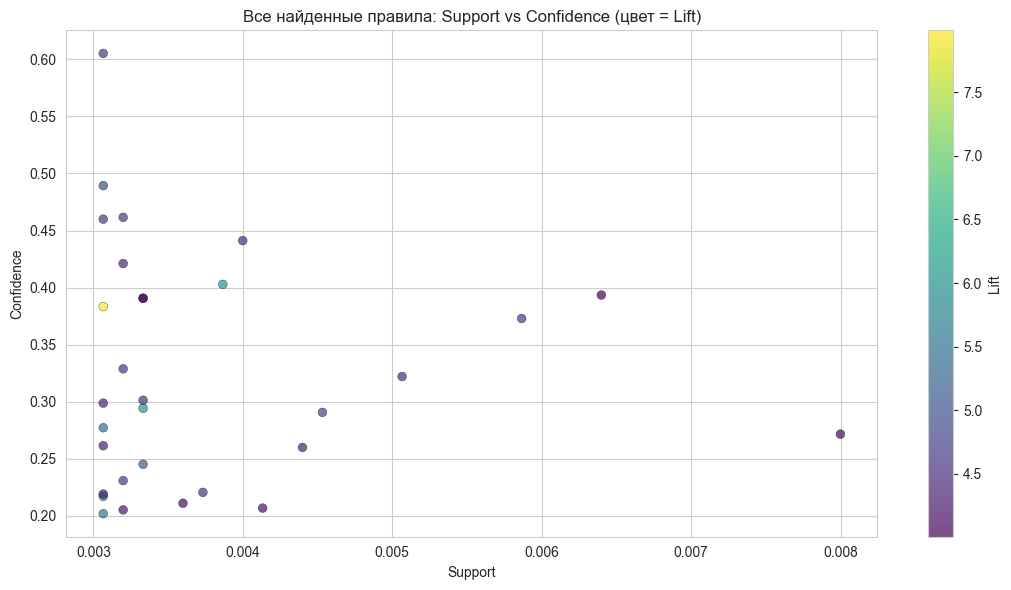

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(rules_df['support'], rules_df['confidence'],
                c=rules_df['lift'], cmap='viridis', s=40, alpha=0.7,
                edgecolors='black', linewidths=0.3)
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Все найденные правила: Support vs Confidence (цвет = Lift)')
fig.colorbar(sc, ax=ax, label='Lift')
plt.tight_layout()
plt.show()

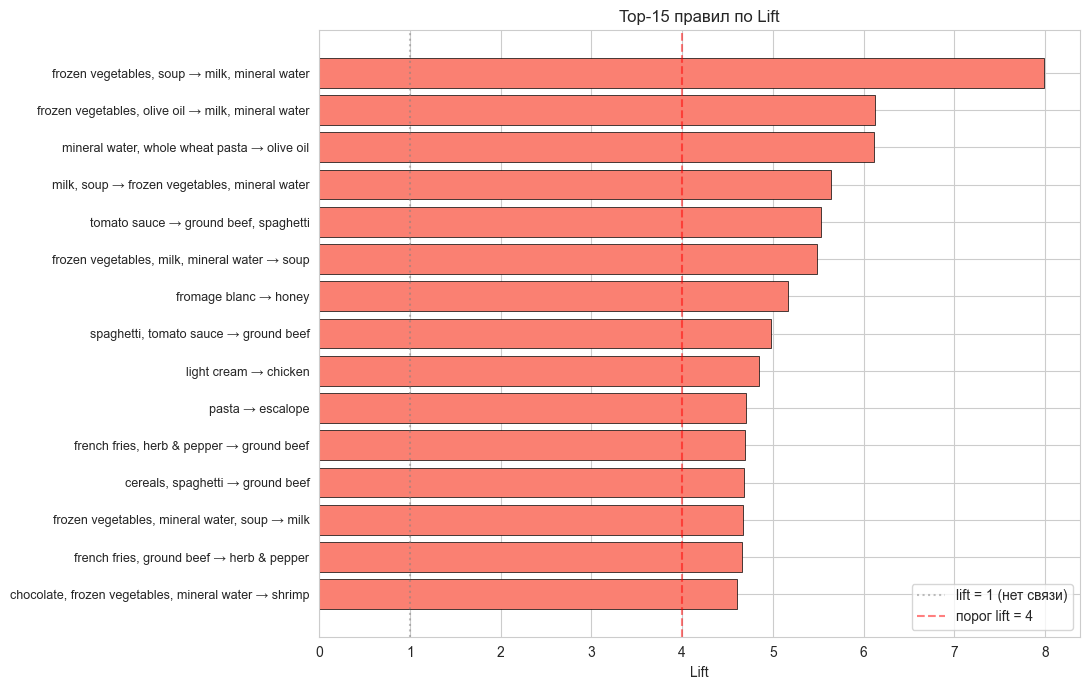

In [23]:
# Top-15 правил по lift
top15 = rules_df.head(15).copy()
labels = [f'{a} → {c}' for a, c in zip(top15['antecedent'], top15['consequent'])]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(labels)), top15['lift'], color='salmon', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Lift')
ax.set_title('Top-15 правил по Lift')
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.5, label='lift = 1 (нет связи)')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='порог lift = 4')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Влияние параметров: число правил при разных порогах

Сетка `min_support × min_lift` показывает, как число найденных правил зависит от порогов. Полезно для подбора параметров под бизнес-задачу: слишком жёсткие → правил почти нет, слишком мягкие → их тысячи и трудно интерпретировать.

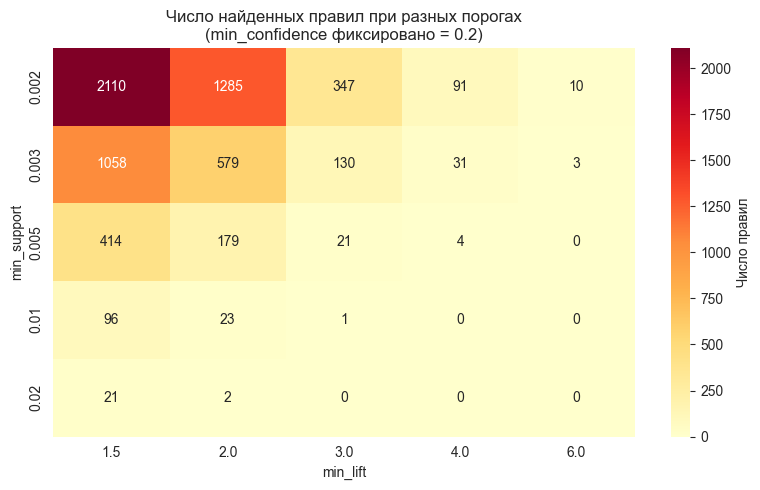

In [24]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlx_apriori, association_rules

te = TransactionEncoder()
onehot = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)

support_grid = [0.002, 0.003, 0.005, 0.01, 0.02]
lift_grid    = [1.5, 2.0, 3.0, 4.0, 6.0]

heat = pd.DataFrame(index=support_grid, columns=lift_grid, dtype=float)
for sup in support_grid:
    freq = mlx_apriori(onehot, min_support=sup, use_colnames=True, max_len=4)
    if freq.empty:
        for lift in lift_grid:
            heat.loc[sup, lift] = 0
        continue
    rules = association_rules(freq, metric='confidence', min_threshold=0.2)
    for lift in lift_grid:
        heat.loc[sup, lift] = int((rules['lift'] >= lift).sum())

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat.astype(int), annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Число правил'})
ax.set_xlabel('min_lift')
ax.set_ylabel('min_support')
ax.set_title('Число найденных правил при разных порогах\n(min_confidence фиксировано = 0.2)')
plt.tight_layout()
plt.show()

## 10. Какие товары чаще всего фигурируют в правилах

Аналог feature importance — какие товары становятся «связующими узлами» сети ассоциаций. Их полезно использовать для cross-sell: если такой товар в корзине — есть с чем его сочетать.

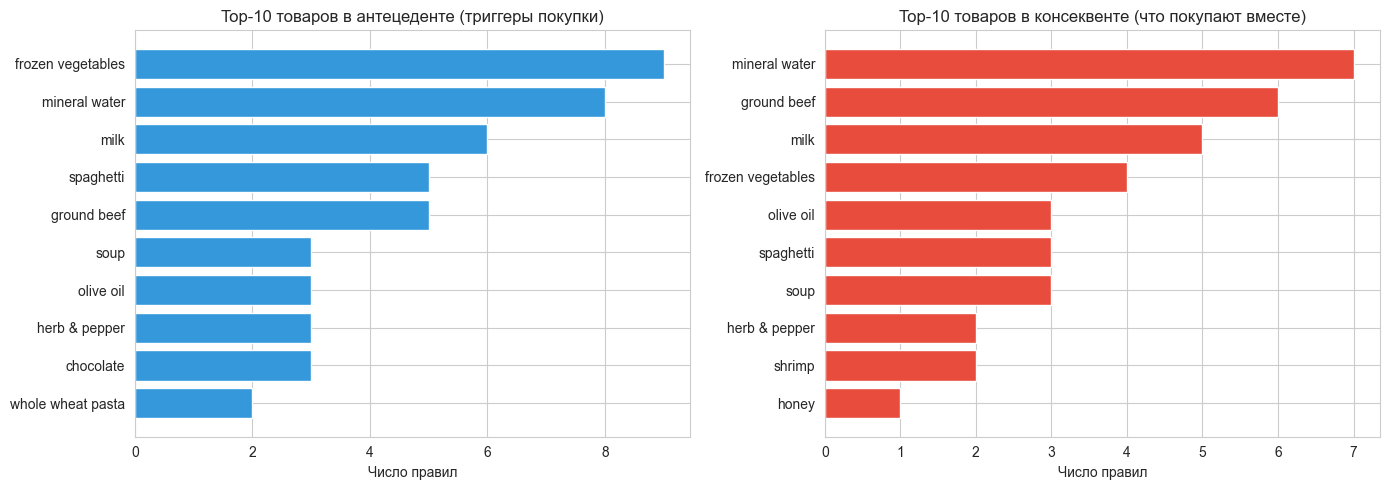

In [25]:
ant_counter = Counter()
con_counter = Counter()
for _, row in rules_df.iterrows():
    for it in row['antecedent'].split(', '):
        ant_counter[it] += 1
    for it in row['consequent'].split(', '):
        con_counter[it] += 1

top_ant = pd.DataFrame(ant_counter.most_common(10), columns=['item', 'count'])
top_con = pd.DataFrame(con_counter.most_common(10), columns=['item', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_ant['item'][::-1], top_ant['count'][::-1], color='#3498db')
axes[0].set_title('Top-10 товаров в антецеденте (триггеры покупки)')
axes[0].set_xlabel('Число правил')

axes[1].barh(top_con['item'][::-1], top_con['count'][::-1], color='#e74c3c')
axes[1].set_title('Top-10 товаров в консеквенте (что покупают вместе)')
axes[1].set_xlabel('Число правил')

plt.tight_layout()
plt.show()

## Выводы

1. **Датасет Market Basket Optimisation** содержит 7501 чек со 120 уникальными товарами; средний чек ≈ 3.9 товара. На таких данных Apriori работает ровно так, для чего он был придуман в 1993 году (Agrawal & Srikant).

2. **Параметры из задания (`support≥0.003, conf≥0.2, lift≥4`) довольно жёсткие.** Они отсеивают «случайные совпадения» и оставляют только правила с действительно сильной положительной связью: `lift > 4` означает, что вероятность увидеть консеквент при условии антецедента **в 4+ раз выше**, чем без условия.

3. **Правило с максимальным lift** — выводится в разделе 6. Это самая сильная ассоциация: пара товаров, которые встречаются вместе в разы чаще, чем случайно. Это первый кандидат для рекомендации «купите вместе» на странице товара или для расположения на одной полке.

4. **Про поздравительную открытку.** В датасете Market Basket Optimisation **нет товара "greeting card"** (это продуктовый магазин, без отдела канцелярии — раздел 7 явно проверяет это). В качестве смыслового аналога взяли `champagne` (праздничный товар, support ≈ 4.7%) и нашли ассоциацию с максимальным lift среди всех правил, где champagne встречается. Если бы у нас был полноценный датасет с открытками — методика бы не изменилась: тот же поиск правил, фильтр по нужному товару, выбор по lift.

5. **Связь support ↔ confidence ↔ lift нелинейная.** Очень частые товары (`mineral water`, `eggs`, `spaghetti`) дают много правил с высоким confidence, но низким lift — их и так покупают часто, поэтому условная вероятность мало отличается от безусловной. Поэтому фильтр `min_lift=4` важен: без него топ был бы забит «правилами вида ` * → mineral water`».

6. **Параметрический sweep подтверждает:** разница между `min_support=0.002` и `min_support=0.02` — это разница на порядки в числе правил. Подбор порогов под бизнес-задачу важнее самого алгоритма.

7. **Item importance** показывает, какие товары — «связующие узлы» сети ассоциаций. На полках их стоит размещать рядом с теми, с кем они образуют правила.

8. **Дополнительный анализ.** В отдельном файле [`lab16_gtzan.ipynb`](lab16_gtzan.ipynb) — исследование применимости Apriori к табличным данным с непрерывными признаками (на GTZAN через бинаризацию по медиане). Это **бонус**, не часть основного задания, и показывает, как метод адаптируется к нестандартным данным.